# 🎯 Post-EKF Fusion Analysis

Reads a rosbag recorded with the dual EKF + NavSat system and plots raw vs fused comparisons.

### Recording command
```bash
source /home/anish/Multi-sensor-fusion/install/setup.bash
ros2 bag record -o /home/rosdata/ekf_fusion_run_$(date +%Y%m%d_%H%M%S) \
  /clock /imu/data /gps/fix /gps/filtered \
  /diff_drive_controller/odom /odometry/local /odometry/global /odometry/gps \
  /cmd_vel /tf /tf_static /joint_states
```
Set `BAG_PATH` below to the **folder** (not the .db3 file) and run all cells.

In [6]:
# ╔══════════════════════════════════════════╗
# ║  CONFIGURE: Set your bag FOLDER here     ║
# ╚══════════════════════════════════════════╝

BAG_PATH = '/home/rosdata/ekf_fusion_run_20260325_235538'

In [15]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rosbags.highlevel import AnyReader
from rosbags.typesys import Stores, get_typestore

# ROS 2 Humble typestore — required for bags that don't embed type defs
typestore = get_typestore(Stores.ROS2_HUMBLE)

# ── Helpers to avoid pandas/matplotlib indexing issues ──
def npcol(df, col):
    return pd.to_numeric(df[col], errors='coerce').to_numpy()

def npxy(df, xcol='x', ycol='y'):
    x = npcol(df, xcol)
    y = npcol(df, ycol)
    mask = np.isfinite(x) & np.isfinite(y)
    return x[mask], y[mask]

# ── Dark theme styling ──
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor': '#16213e',
    'axes.edgecolor': '#e0e0e0',
    'axes.labelcolor': '#e0e0e0',
    'text.color': '#e0e0e0',
    'xtick.color': '#aaaaaa',
    'ytick.color': '#aaaaaa',
    'grid.color': '#2a2a4a',
    'grid.alpha': 0.5,
    'legend.facecolor': '#16213e',
    'legend.edgecolor': '#444444',
    'font.size': 11,
})

COLORS = {
    'raw_odom':   '#ff6b6b',
    'ekf_local':  '#51cf66',
    'ekf_global': '#339af0',
    'gps':        '#ffd43b',
    'gps_odom':   '#ff922b',
    'cmd_vel':    '#cc5de8',
    'imu':        '#20c997',
}

PLOT_DIR = '/home/anish/Multi-sensor-fusion/plots'
os.makedirs(PLOT_DIR, exist_ok=True)

print('Imports OK ✓')
print(f'Typestore: ROS2_HUMBLE')
print(f'Bag path: {BAG_PATH}')
print(f'Bag exists: {Path(BAG_PATH).exists()}')

Imports OK ✓
Typestore: ROS2_HUMBLE
Bag path: /home/rosdata/ekf_fusion_run_20260325_235538
Bag exists: True


## 1. Extract Data from Rosbag

In [16]:
def quat_to_yaw(q):
    """Extract yaw from a quaternion using atan2."""
    siny_cosp = 2.0 * (q.w * q.z + q.x * q.y)
    cosy_cosp = 1.0 - 2.0 * (q.y * q.y + q.z * q.z)
    return np.arctan2(siny_cosp, cosy_cosp)


def extract_topics(bag_path):
    data = {
        'raw_odom': [], 'ekf_local': [], 'ekf_global': [],
        'gps_fix': [], 'gps_odom': [], 'cmd_vel': [], 'imu': [],
    }

    with AnyReader([Path(bag_path)], default_typestore=typestore) as reader:
        print(f'Reading bag: {bag_path}')
        print(f'Topics found: {list(reader.topics.keys())}')

        for connection, timestamp, rawdata in reader.messages():
            msg = reader.deserialize(rawdata, connection.msgtype)
            t_sec = timestamp * 1e-9

            if connection.topic == '/diff_drive_controller/odom':
                data['raw_odom'].append({
                    't': t_sec,
                    'x': msg.pose.pose.position.x,
                    'y': msg.pose.pose.position.y,
                    'vx': msg.twist.twist.linear.x,
                    'vyaw': msg.twist.twist.angular.z,
                    'yaw': quat_to_yaw(msg.pose.pose.orientation),
                })
            elif connection.topic == '/odometry/local':
                data['ekf_local'].append({
                    't': t_sec,
                    'x': msg.pose.pose.position.x,
                    'y': msg.pose.pose.position.y,
                    'vx': msg.twist.twist.linear.x,
                    'vyaw': msg.twist.twist.angular.z,
                    'yaw': quat_to_yaw(msg.pose.pose.orientation),
                })
            elif connection.topic == '/odometry/global':
                data['ekf_global'].append({
                    't': t_sec,
                    'x': msg.pose.pose.position.x,
                    'y': msg.pose.pose.position.y,
                    'vx': msg.twist.twist.linear.x,
                    'vyaw': msg.twist.twist.angular.z,
                    'yaw': quat_to_yaw(msg.pose.pose.orientation),
                })
            elif connection.topic == '/gps/fix':
                data['gps_fix'].append({
                    't': t_sec,
                    'lat': msg.latitude, 'lon': msg.longitude, 'alt': msg.altitude,
                })
            elif connection.topic == '/odometry/gps':
                data['gps_odom'].append({
                    't': t_sec,
                    'x': msg.pose.pose.position.x,
                    'y': msg.pose.pose.position.y,
                })
            elif connection.topic == '/cmd_vel':
                data['cmd_vel'].append({
                    't': t_sec,
                    'vx': msg.linear.x, 'vyaw': msg.angular.z,
                })
            elif connection.topic == '/imu/data':
                data['imu'].append({
                    't': t_sec,
                    'yaw': quat_to_yaw(msg.orientation),
                    'gyro_z': msg.angular_velocity.z,
                    'accel_x': msg.linear_acceleration.x,
                    'accel_y': msg.linear_acceleration.y,
                })

    # Convert to DataFrames, normalize time
    dfs = {}
    t0 = float('inf')
    for key, rows in data.items():
        if rows:
            df = pd.DataFrame(rows)
            t0 = min(t0, df['t'].iloc[0])
            dfs[key] = df
    for key in dfs:
        dfs[key]['t'] -= t0

    return dfs


# ── Run extraction ──
dfs = extract_topics(BAG_PATH)

# ── Summary table ──
print('\n' + '=' * 65)
print(f'{"Source":>20s}  {"Messages":>8s}  {"Duration":>8s}  {"Rate":>7s}')
print('=' * 65)
for name, df in dfs.items():
    dur = df['t'].iloc[-1] - df['t'].iloc[0] if len(df) > 1 else 0
    hz = len(df) / dur if dur > 0 else 0
    print(f'{name:>20s}  {len(df):8d}  {dur:7.1f}s  {hz:6.1f} Hz')
print('=' * 65)

Reading bag: /home/rosdata/ekf_fusion_run_20260325_235538
Topics found: ['/clock', '/cmd_vel', '/diff_drive_controller/odom', '/gps/filtered', '/gps/fix', '/imu/data', '/joint_states', '/lidar/points', '/odometry/global', '/odometry/gps', '/odometry/local', '/tf', '/tf_static']

              Source  Messages  Duration     Rate
            raw_odom      7375    153.8s    47.9 Hz
           ekf_local      7375    153.8s    47.9 Hz
          ekf_global      7375    153.8s    47.9 Hz
             gps_fix      1475    153.7s     9.6 Hz
            gps_odom      1470    153.7s     9.6 Hz
             cmd_vel      4066    153.8s    26.4 Hz
                 imu     29499    153.8s   191.8 Hz


## 2. XY Trajectory Comparison

Raw wheel odom vs EKF local vs EKF global vs GPS scatter.

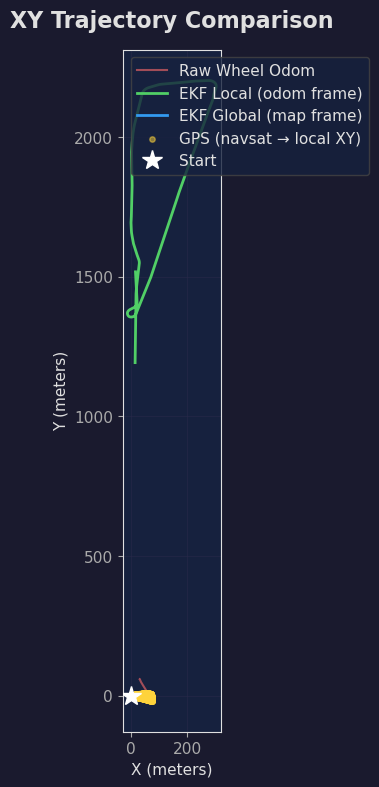

Saved: plots/ekf_xy_trajectory.png


In [17]:
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle('XY Trajectory Comparison', fontsize=16, fontweight='bold')

if 'raw_odom' in dfs:
    x, y = npxy(dfs['raw_odom'], 'x', 'y')
    ax.plot(x, y, color=COLORS['raw_odom'], alpha=0.6, lw=1.5, label='Raw Wheel Odom')
if 'ekf_local' in dfs:
    x, y = npxy(dfs['ekf_local'], 'x', 'y')
    ax.plot(x, y, color=COLORS['ekf_local'], lw=2, label='EKF Local (odom frame)')
if 'ekf_global' in dfs:
    x, y = npxy(dfs['ekf_global'], 'x', 'y')
    ax.plot(x, y, color=COLORS['ekf_global'], lw=2, label='EKF Global (map frame)')
if 'gps_odom' in dfs:
    x, y = npxy(dfs['gps_odom'], 'x', 'y')
    ax.scatter(x, y, color=COLORS['gps'], s=15, alpha=0.5, zorder=5,
               label='GPS (navsat → local XY)')

ax.plot(0, 0, 'w*', markersize=15, zorder=10, label='Start')
ax.set_xlabel('X (meters)')
ax.set_ylabel('Y (meters)')
ax.legend(loc='upper left')
ax.set_aspect('equal')
ax.grid(True)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/ekf_xy_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/ekf_xy_trajectory.png')

## 3. Velocity: Commanded vs Raw vs EKF-Fused

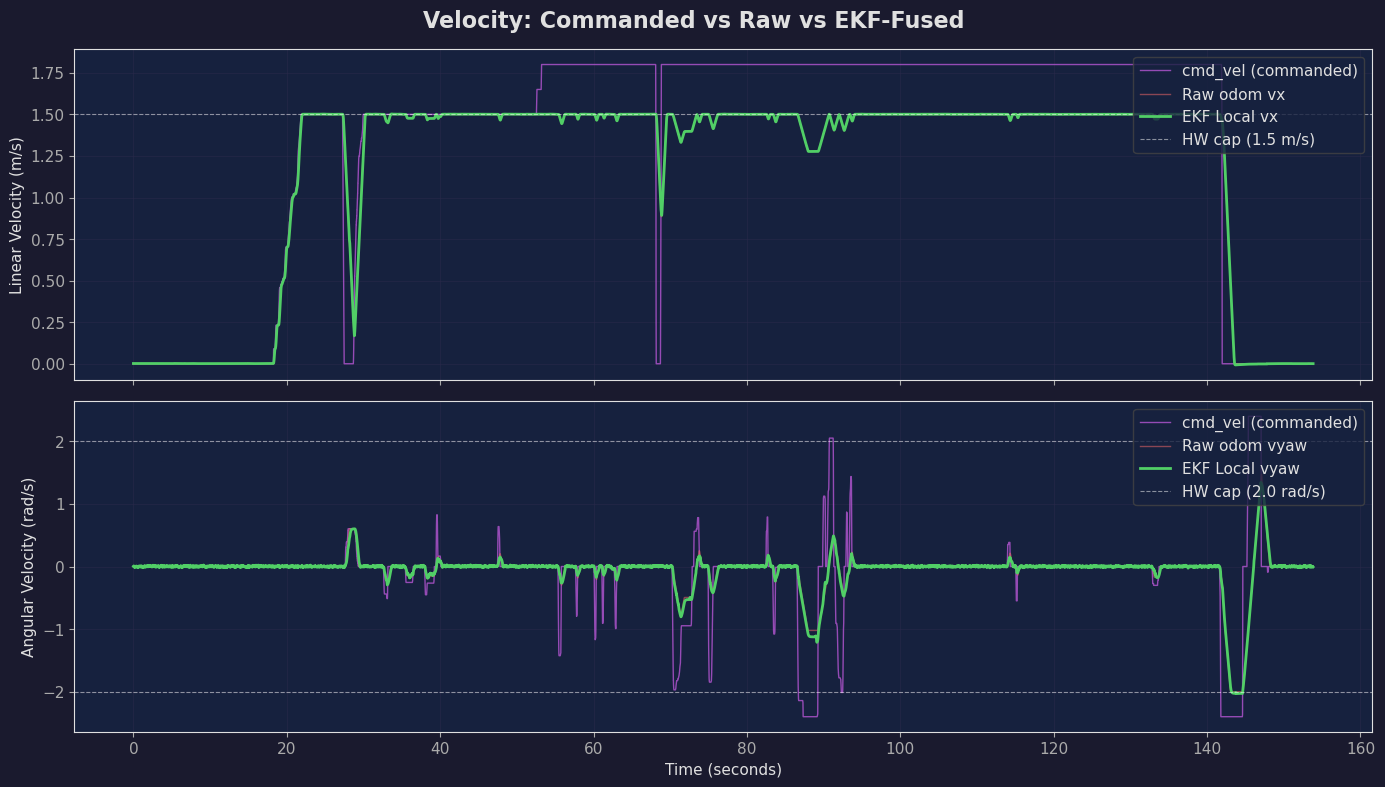

Saved: plots/ekf_velocity_comparison.png


In [18]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Velocity: Commanded vs Raw vs EKF-Fused', fontsize=16, fontweight='bold')

if 'cmd_vel' in dfs:
    t = npcol(dfs['cmd_vel'], 't')
    vx = npcol(dfs['cmd_vel'], 'vx')
    m = np.isfinite(t) & np.isfinite(vx)
    ax1.plot(t[m], vx[m], color=COLORS['cmd_vel'], alpha=0.7, lw=1, label='cmd_vel (commanded)')
if 'raw_odom' in dfs:
    t = npcol(dfs['raw_odom'], 't')
    vx = npcol(dfs['raw_odom'], 'vx')
    m = np.isfinite(t) & np.isfinite(vx)
    ax1.plot(t[m], vx[m], color=COLORS['raw_odom'], alpha=0.5, lw=1, label='Raw odom vx')
if 'ekf_local' in dfs:
    t = npcol(dfs['ekf_local'], 't')
    vx = npcol(dfs['ekf_local'], 'vx')
    m = np.isfinite(t) & np.isfinite(vx)
    ax1.plot(t[m], vx[m], color=COLORS['ekf_local'], lw=2, label='EKF Local vx')
ax1.axhline(1.5, color='white', ls='--', lw=0.8, alpha=0.5, label='HW cap (1.5 m/s)')
ax1.set_ylabel('Linear Velocity (m/s)')
ax1.legend(loc='upper right')
ax1.grid(True)

if 'cmd_vel' in dfs:
    t = npcol(dfs['cmd_vel'], 't')
    wz = npcol(dfs['cmd_vel'], 'vyaw')
    m = np.isfinite(t) & np.isfinite(wz)
    ax2.plot(t[m], wz[m], color=COLORS['cmd_vel'], alpha=0.7, lw=1, label='cmd_vel (commanded)')
if 'raw_odom' in dfs:
    t = npcol(dfs['raw_odom'], 't')
    wz = npcol(dfs['raw_odom'], 'vyaw')
    m = np.isfinite(t) & np.isfinite(wz)
    ax2.plot(t[m], wz[m], color=COLORS['raw_odom'], alpha=0.5, lw=1, label='Raw odom vyaw')
if 'ekf_local' in dfs:
    t = npcol(dfs['ekf_local'], 't')
    wz = npcol(dfs['ekf_local'], 'vyaw')
    m = np.isfinite(t) & np.isfinite(wz)
    ax2.plot(t[m], wz[m], color=COLORS['ekf_local'], lw=2, label='EKF Local vyaw')
ax2.axhline(2.0, color='white', ls='--', lw=0.8, alpha=0.5, label='HW cap (2.0 rad/s)')
ax2.axhline(-2.0, color='white', ls='--', lw=0.8, alpha=0.5)
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Angular Velocity (rad/s)')
ax2.legend(loc='upper right')
ax2.grid(True)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/ekf_velocity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/ekf_velocity_comparison.png')

## 4. Yaw Estimate: Raw Odom vs EKF (IMU-Fused)

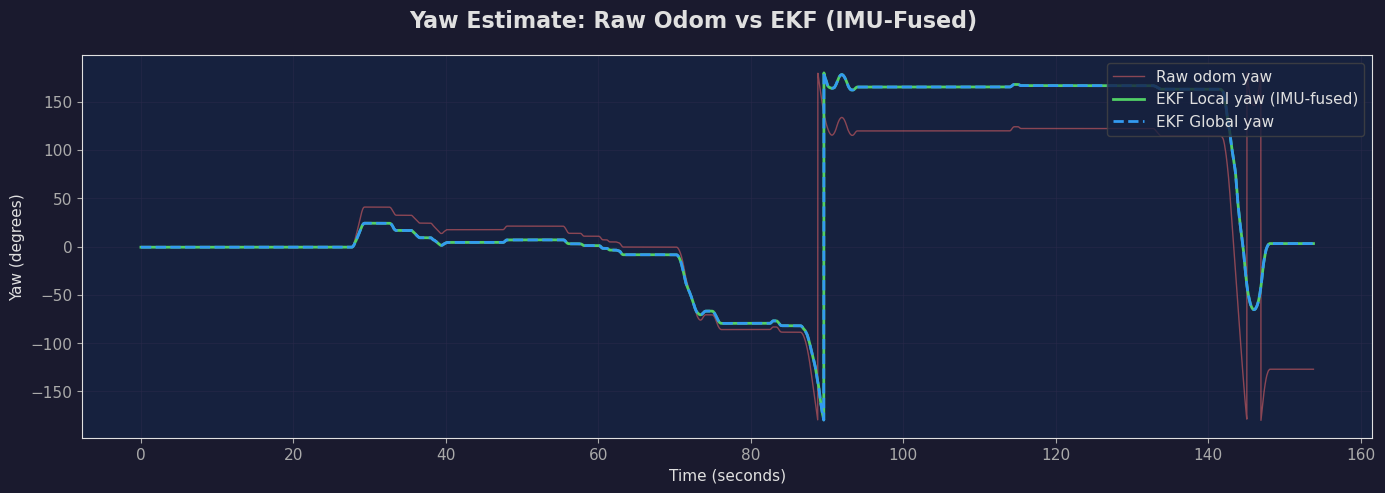

Saved: plots/ekf_yaw_comparison.png


In [19]:
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Yaw Estimate: Raw Odom vs EKF (IMU-Fused)', fontsize=16, fontweight='bold')

if 'raw_odom' in dfs:
    t = npcol(dfs['raw_odom'], 't')
    yaw_deg = np.degrees(npcol(dfs['raw_odom'], 'yaw'))
    m = np.isfinite(t) & np.isfinite(yaw_deg)
    ax.plot(t[m], yaw_deg[m], color=COLORS['raw_odom'], alpha=0.5, lw=1, label='Raw odom yaw')
if 'ekf_local' in dfs:
    t = npcol(dfs['ekf_local'], 't')
    yaw_deg = np.degrees(npcol(dfs['ekf_local'], 'yaw'))
    m = np.isfinite(t) & np.isfinite(yaw_deg)
    ax.plot(t[m], yaw_deg[m], color=COLORS['ekf_local'], lw=2, label='EKF Local yaw (IMU-fused)')
if 'ekf_global' in dfs:
    t = npcol(dfs['ekf_global'], 't')
    yaw_deg = np.degrees(npcol(dfs['ekf_global'], 'yaw'))
    m = np.isfinite(t) & np.isfinite(yaw_deg)
    ax.plot(t[m], yaw_deg[m], color=COLORS['ekf_global'], lw=2, ls='--', label='EKF Global yaw')

ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Yaw (degrees)')
ax.legend(loc='upper right')
ax.grid(True)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/ekf_yaw_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/ekf_yaw_comparison.png')

## 5. GPS Noise Reduction by EKF

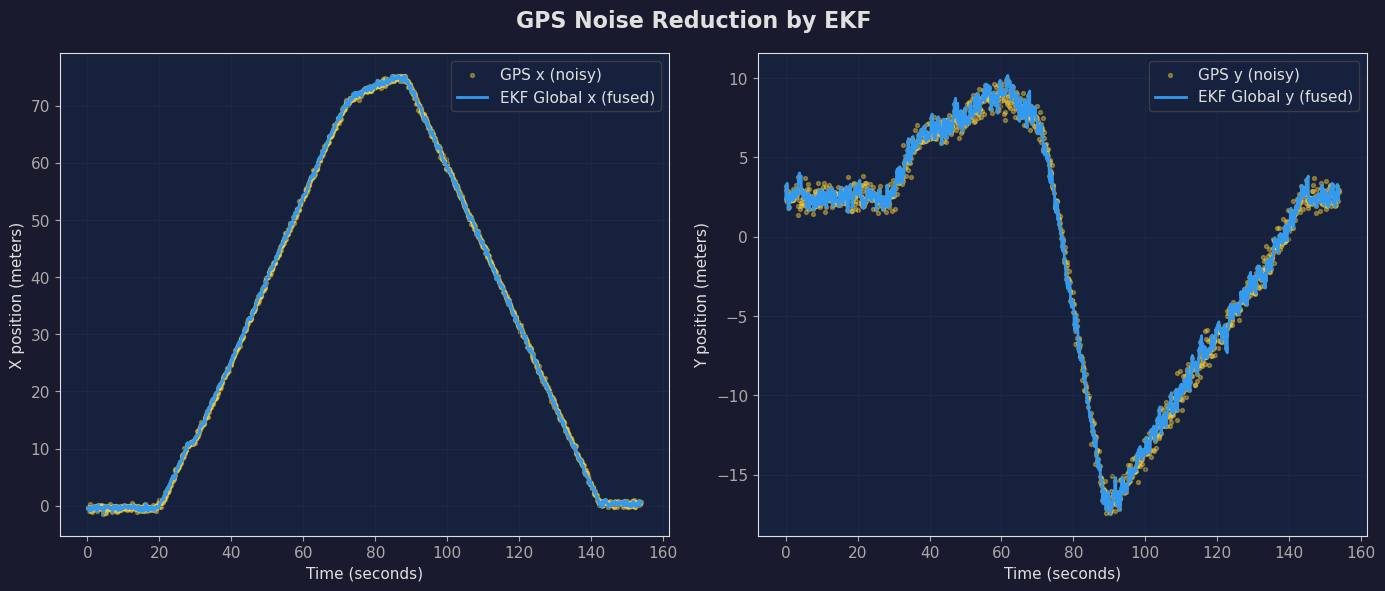

Saved: plots/ekf_gps_noise_reduction.png


In [20]:
if 'gps_odom' in dfs and 'ekf_global' in dfs:
    gps = dfs['gps_odom']
    ekf = dfs['ekf_global']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('GPS Noise Reduction by EKF', fontsize=16, fontweight='bold')

    tg = npcol(gps, 't')
    xg = npcol(gps, 'x')
    yg = npcol(gps, 'y')
    te = npcol(ekf, 't')
    xe = npcol(ekf, 'x')
    ye = npcol(ekf, 'y')

    m1 = np.isfinite(tg) & np.isfinite(xg)
    m2 = np.isfinite(te) & np.isfinite(xe)
    ax1.scatter(tg[m1], xg[m1], color=COLORS['gps'], s=8, alpha=0.4, label='GPS x (noisy)')
    ax1.plot(te[m2], xe[m2], color=COLORS['ekf_global'], lw=2, label='EKF Global x (fused)')
    ax1.set_xlabel('Time (seconds)')
    ax1.set_ylabel('X position (meters)')
    ax1.legend()
    ax1.grid(True)

    m3 = np.isfinite(tg) & np.isfinite(yg)
    m4 = np.isfinite(te) & np.isfinite(ye)
    ax2.scatter(tg[m3], yg[m3], color=COLORS['gps'], s=8, alpha=0.4, label='GPS y (noisy)')
    ax2.plot(te[m4], ye[m4], color=COLORS['ekf_global'], lw=2, label='EKF Global y (fused)')
    ax2.set_xlabel('Time (seconds)')
    ax2.set_ylabel('Y position (meters)')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/ekf_gps_noise_reduction.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: plots/ekf_gps_noise_reduction.png')
else:
    print('⚠ Skipping — missing /odometry/gps or /odometry/global')

## 6. Innovation Analysis (GPS − EKF Estimate)

If well-tuned: zero-mean Gaussian noise, circular scatter at origin.

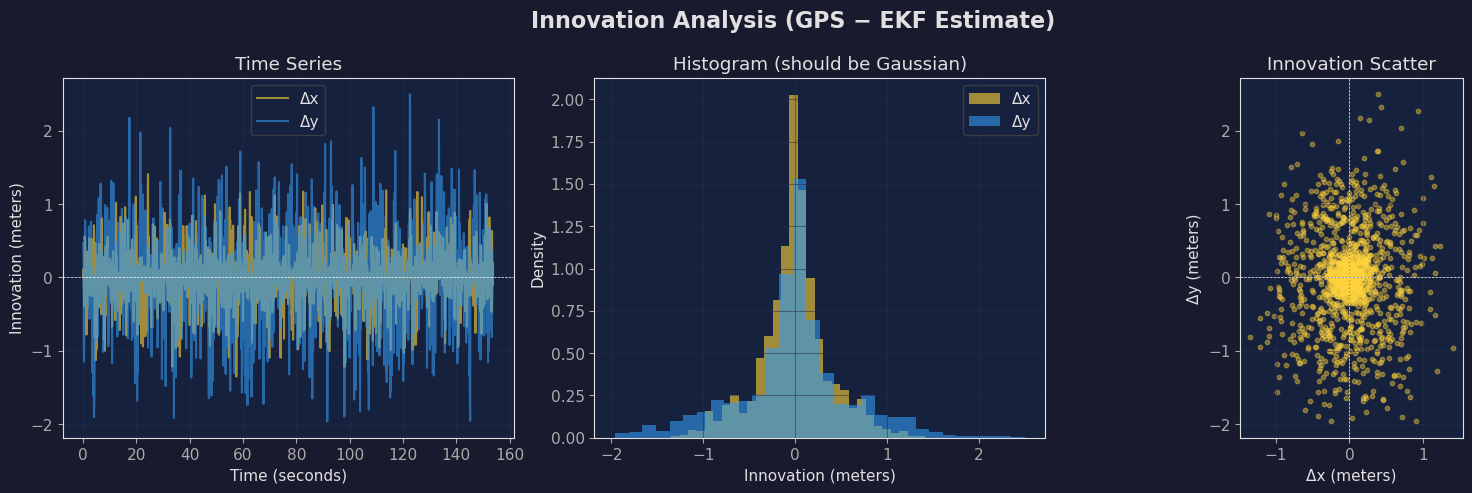

Saved: plots/ekf_innovation.png

--- Innovation Statistics ---
  Δx: mean=-0.0080 m, std=0.3785 m
  Δy: mean=-0.0154 m, std=0.6177 m
  RMSE: 0.7247 m


In [21]:
if 'gps_odom' in dfs and 'ekf_global' in dfs:
    gps = dfs['gps_odom']
    ekf = dfs['ekf_global']

    t_gps = npcol(gps, 't')
    x_gps = npcol(gps, 'x')
    y_gps = npcol(gps, 'y')
    t_ekf = npcol(ekf, 't')
    x_ekf = npcol(ekf, 'x')
    y_ekf = npcol(ekf, 'y')

    mg = np.isfinite(t_gps) & np.isfinite(x_gps) & np.isfinite(y_gps)
    me = np.isfinite(t_ekf) & np.isfinite(x_ekf) & np.isfinite(y_ekf)
    t_gps = t_gps[mg]
    x_gps = x_gps[mg]
    y_gps = y_gps[mg]
    t_ekf = t_ekf[me]
    x_ekf = x_ekf[me]
    y_ekf = y_ekf[me]

    if len(t_gps) == 0 or len(t_ekf) == 0:
        print('⚠ Skipping — no valid finite points after cleaning.')
    else:
        ekf_x_interp = np.interp(t_gps, t_ekf, x_ekf)
        ekf_y_interp = np.interp(t_gps, t_ekf, y_ekf)
        innov_x = x_gps - ekf_x_interp
        innov_y = y_gps - ekf_y_interp

        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        fig.suptitle('Innovation Analysis (GPS − EKF Estimate)', fontsize=16, fontweight='bold')

        axes[0].plot(t_gps, innov_x, color=COLORS['gps'], alpha=0.6, label='Δx')
        axes[0].plot(t_gps, innov_y, color=COLORS['ekf_global'], alpha=0.6, label='Δy')
        axes[0].axhline(0, color='white', lw=0.5, ls='--')
        axes[0].set_xlabel('Time (seconds)')
        axes[0].set_ylabel('Innovation (meters)')
        axes[0].legend()
        axes[0].grid(True)
        axes[0].set_title('Time Series')

        axes[1].hist(innov_x, bins=30, color=COLORS['gps'], alpha=0.6, label='Δx', density=True)
        axes[1].hist(innov_y, bins=30, color=COLORS['ekf_global'], alpha=0.6, label='Δy', density=True)
        axes[1].set_xlabel('Innovation (meters)')
        axes[1].set_ylabel('Density')
        axes[1].legend()
        axes[1].grid(True)
        axes[1].set_title('Histogram (should be Gaussian)')

        axes[2].scatter(innov_x, innov_y, color=COLORS['gps'], s=10, alpha=0.4)
        axes[2].axhline(0, color='white', lw=0.5, ls='--')
        axes[2].axvline(0, color='white', lw=0.5, ls='--')
        axes[2].set_xlabel('Δx (meters)')
        axes[2].set_ylabel('Δy (meters)')
        axes[2].set_aspect('equal')
        axes[2].grid(True)
        axes[2].set_title('Innovation Scatter')

        plt.tight_layout()
        plt.savefig(f'{PLOT_DIR}/ekf_innovation.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('Saved: plots/ekf_innovation.png')

        rmse = np.sqrt(np.mean(innov_x**2 + innov_y**2))
        print(f'\n--- Innovation Statistics ---')
        print(f'  Δx: mean={innov_x.mean():.4f} m, std={innov_x.std():.4f} m')
        print(f'  Δy: mean={innov_y.mean():.4f} m, std={innov_y.std():.4f} m')
        print(f'  RMSE: {rmse:.4f} m')
else:
    print('⚠ Skipping — missing data.')

## 7. EKF Drift Analysis

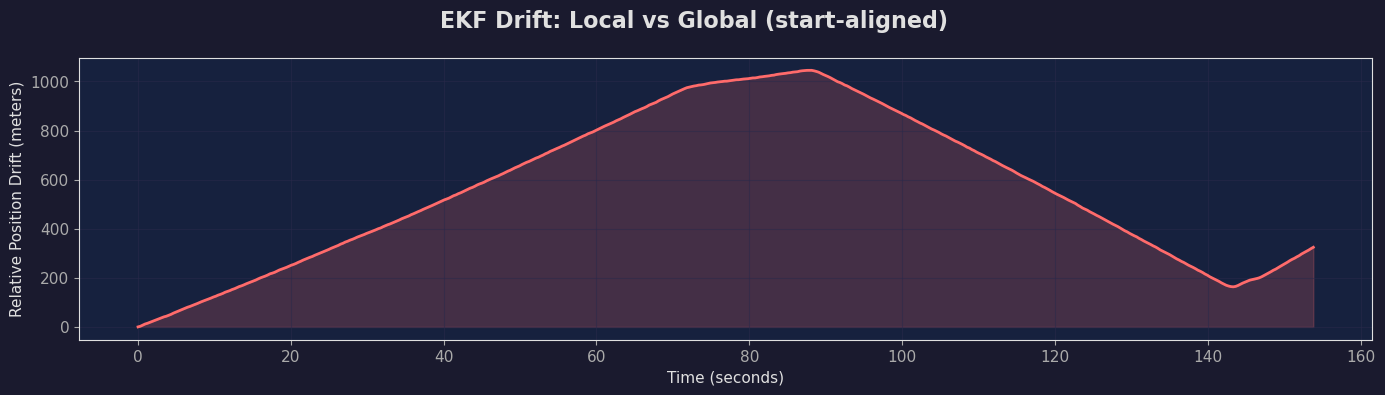

Saved: plots/ekf_drift.png

--- Drift Summary (start-aligned) ---
  Final drift: 324.347 m over 153.8s
  Drift rate:  126.517 m/min
  Max drift:   1045.109 m


In [23]:
if 'ekf_local' in dfs and 'ekf_global' in dfs:
    local = dfs['ekf_local']
    glob_ = dfs['ekf_global']

    tl = npcol(local, 't')
    xl = npcol(local, 'x')
    yl = npcol(local, 'y')
    tg = npcol(glob_, 't')
    xg = npcol(glob_, 'x')
    yg = npcol(glob_, 'y')

    ml = np.isfinite(tl) & np.isfinite(xl) & np.isfinite(yl)
    mg = np.isfinite(tg) & np.isfinite(xg) & np.isfinite(yg)
    tl, xl, yl = tl[ml], xl[ml], yl[ml]
    tg, xg, yg = tg[mg], xg[mg], yg[mg]

    if len(tl) < 2 or len(tg) < 2:
        print('⚠ Not enough valid points for drift analysis.')
    else:
        t_common = np.linspace(
            max(tl[0], tg[0]),
            min(tl[-1], tg[-1]),
            500
        )
        local_x = np.interp(t_common, tl, xl)
        local_y = np.interp(t_common, tl, yl)
        glob_x = np.interp(t_common, tg, xg)
        glob_y = np.interp(t_common, tg, yg)

        # Compare relative motion (start-aligned) to avoid frame-origin bias
        local_x_rel = local_x - local_x[0]
        local_y_rel = local_y - local_y[0]
        glob_x_rel = glob_x - glob_x[0]
        glob_y_rel = glob_y - glob_y[0]
        drift = np.sqrt((local_x_rel - glob_x_rel)**2 + (local_y_rel - glob_y_rel)**2)

        fig, ax = plt.subplots(figsize=(14, 4))
        fig.suptitle('EKF Drift: Local vs Global (start-aligned)', fontsize=16, fontweight='bold')
        ax.plot(t_common, drift, color=COLORS['raw_odom'], lw=2)
        ax.fill_between(t_common, 0, drift, color=COLORS['raw_odom'], alpha=0.2)
        ax.set_xlabel('Time (seconds)')
        ax.set_ylabel('Relative Position Drift (meters)')
        ax.grid(True)
        plt.tight_layout()
        plt.savefig(f'{PLOT_DIR}/ekf_drift.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('Saved: plots/ekf_drift.png')

        duration = t_common[-1] - t_common[0]
        print(f'\n--- Drift Summary (start-aligned) ---')
        print(f'  Final drift: {drift[-1]:.3f} m over {duration:.1f}s')
        print(f'  Drift rate:  {drift[-1] / duration * 60:.3f} m/min')
        print(f'  Max drift:   {drift.max():.3f} m')
else:
    print('⚠ Need both /odometry/local and /odometry/global')